Running the pipeline for lung dataset

In [1]:
import sys
import os
from pathlib import Path

REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()
os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

from scrna_benchmark.config import DatasetConfig
from scrna_benchmark.pipeline import run_dataset_benchmark

representations = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}

config_no_batch = DatasetConfig(
    dataset_name="lung_no_batch_L4",
    adata_path="data/lung/lung_benchmark_ready.h5ad",
    output_dir="results",

    celltype_col="cell_type",
    donor_col="donor_id",
    batch_col=None,
    group_col="batch",

    representations=representations,

    min_cells=500,
    min_donors=10,

    run_random_split=True,
    run_donor_cv=True,
    run_group_transfer=False,

    run_donor_ablation=True,
    donor_ablation_k_values=[5, 10, 20, 40, 80],
    donor_ablation_n_repeats=5,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_no_batch = run_dataset_benchmark(config_no_batch)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)

Running donor ablation for hvg (hvg)
  k= 5, repeat=1: macro_f1=0.8205, acc=0.8042
  k= 5, repeat=2: macro_f1=0.6934, acc=0.7226
  k= 5, repeat=3: macr

In [2]:
# ============================================================
# Benchmark Set 2: source-dataset covariate in classifier
# ============================================================

config_with_batch = DatasetConfig(
    dataset_name="lung_with_batch_L4",
    adata_path="data/lung/lung_benchmark_ready.h5ad",
    output_dir="results",

    celltype_col="cell_type",
    donor_col="donor_id",
    batch_col="batch",

    # no group-transfer experiment in this sensitivity run
    group_col=None,

    representations=representations,

    min_cells=500,
    min_donors=10,

    run_random_split=True,
    run_donor_cv=True,

    # already done under the primary configuration
    run_group_transfer=False,
    run_donor_ablation=False,

    test_size=0.2,
    n_folds=5,
    random_state=42,

    save_filtered_adata=False,
    verbose=True,
)

outputs_with_batch = run_dataset_benchmark(config_with_batch)

Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running random_split: hvg (hvg)
Running random_split: pca (X_pca)
Running random_split: harmony (X_harmony)
Running random_split: scvi (X_scVI)
Running donor_cv: hvg (hvg)
Running donor_cv: pca (X_pca)
Running donor_cv: harmony (X_harmony)
Running donor_cv: scvi (X_scVI)


**Plots**

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

from scrna_benchmark.plotting import (
    plot_random_vs_donor_cv,
    plot_batch_covariate_comparison,
    plot_donor_ablation,
    load_per_class_f1_matrix,
    plot_per_class_f1_heatmap,
    plot_confusion_matrix_from_predictions,
    plot_glmm_scheme_comparison,
)

REP_ORDER = ["hvg", "pca", "harmony", "scvi"]

REP_LABELS = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}

figures_dir = config_no_batch.dataset_output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

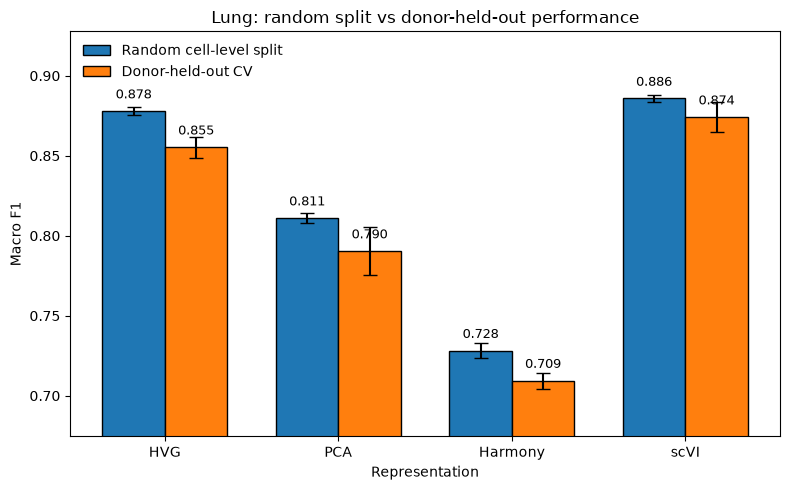

In [4]:
fig, ax = plot_random_vs_donor_cv(
    random_metrics=(
        config_no_batch.random_output_dir
        / "random_split_repeated_metrics.csv"
    ),
    donor_metrics=(
        config_no_batch.donor_cv_output_dir
        / "metrics.csv"
    ),
    rep_order=REP_ORDER,
    rep_labels=REP_LABELS,
    out_file=(
        figures_dir
        / "random_vs_donor_cv.png"
    ),
    title="Lung: random split vs donor-held-out performance",
)

plt.show()

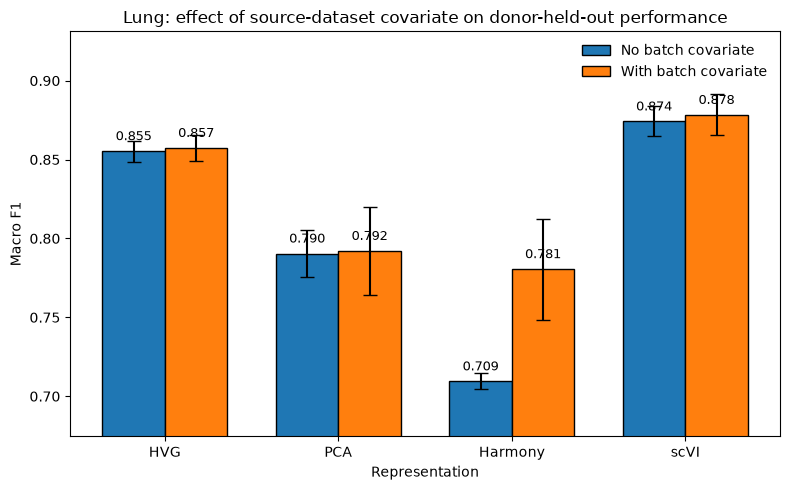

In [5]:
fig, ax = plot_batch_covariate_comparison(
    no_batch_metrics=(
        config_no_batch.donor_cv_output_dir
        / "metrics.csv"
    ),
    with_batch_metrics=(
        config_with_batch.donor_cv_output_dir
        / "metrics.csv"
    ),
    rep_order=REP_ORDER,
    rep_labels=REP_LABELS,
    out_file=(
        figures_dir
        / "batch_covariate_donor_cv.png"
    ),
    title=(
        "Lung: effect of source-dataset covariate "
        "on donor-held-out performance"
    ),
)

plt.show()

In [9]:
import pandas as pd
ablation_summary = pd.read_csv(
    config_no_batch.donor_ablation_output_dir
    / "donor_ablation_summary.csv"
)

display(
    ablation_summary[
        [
            "representation",
            "k_train_donors",
            "macro_f1_mean",
            "macro_f1_std",
            "mean_n_classes_used",
        ]
    ]
)

ablation_summary.groupby("k_train_donors")[
    "mean_n_classes_used"
].mean()

,representation,k_train_donors,macro_f1_mean,macro_f1_std,mean_n_classes_used
0,harmony,5,0.613319,0.042671,28.8
1,harmony,10,0.637249,0.027194,29.8
2,harmony,20,0.672979,0.006515,30.0
3,harmony,40,0.699209,0.009599,30.0
4,harmony,80,0.708320,0.015554,30.0
5,hvg,5,0.778505,0.053287,28.8
6,hvg,10,0.814964,0.024689,29.8
7,hvg,20,0.833769,0.006997,30.0
8,hvg,40,0.849792,0.005073,30.0
9,hvg,80,0.859581,0.012317,30.0


k_train_donors
5     28.8
10    29.8
20    30.0
40    30.0
80    30.0
Name: mean_n_classes_used, dtype: float64

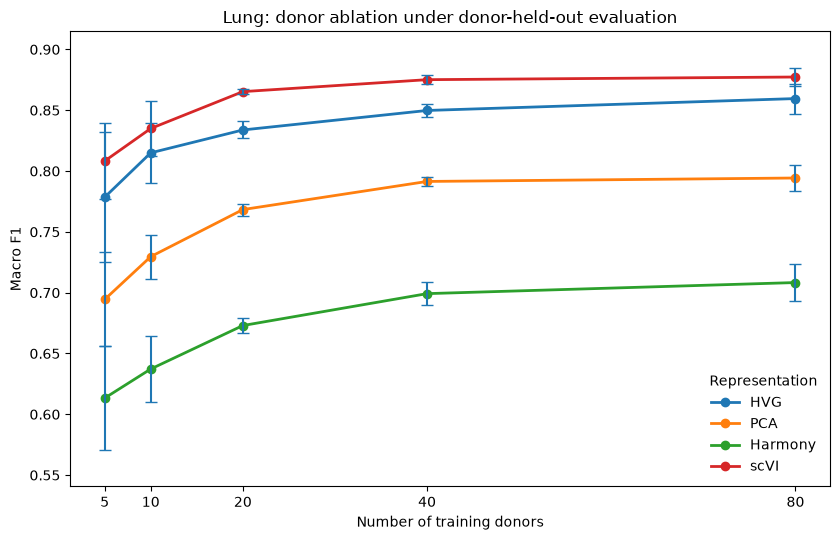

In [6]:
fig, ax = plot_donor_ablation(
    summary_df=(
        config_no_batch.donor_ablation_output_dir
        / "donor_ablation_summary.csv"
    ),
    rep_order=REP_ORDER,
    rep_labels=REP_LABELS,
    out_file=(
        figures_dir
        / "donor_ablation.png"
    ),
    title="Lung: donor ablation under donor-held-out evaluation",
)

plt.show()

,hvg,pca,harmony,scvi
cell_type,,,,
Multiciliated,0.970398,0.960963,0.960354,0.977923
Pericytes,0.981775,0.912090,0.884806,0.985385
B cells,0.976000,0.889469,0.864232,0.973775
SMG serous,0.922041,0.922139,0.870898,0.926156
AT2 proliferating,0.950879,0.907356,0.788998,0.973027
EC aerocyte capillary,0.920317,0.892108,0.851784,0.927673
Plasma cells,0.978038,0.835377,0.725593,0.988297
NK cells,0.898301,0.839490,0.823210,0.916985
CD4 T cells,0.865362,0.842947,0.791255,0.892219


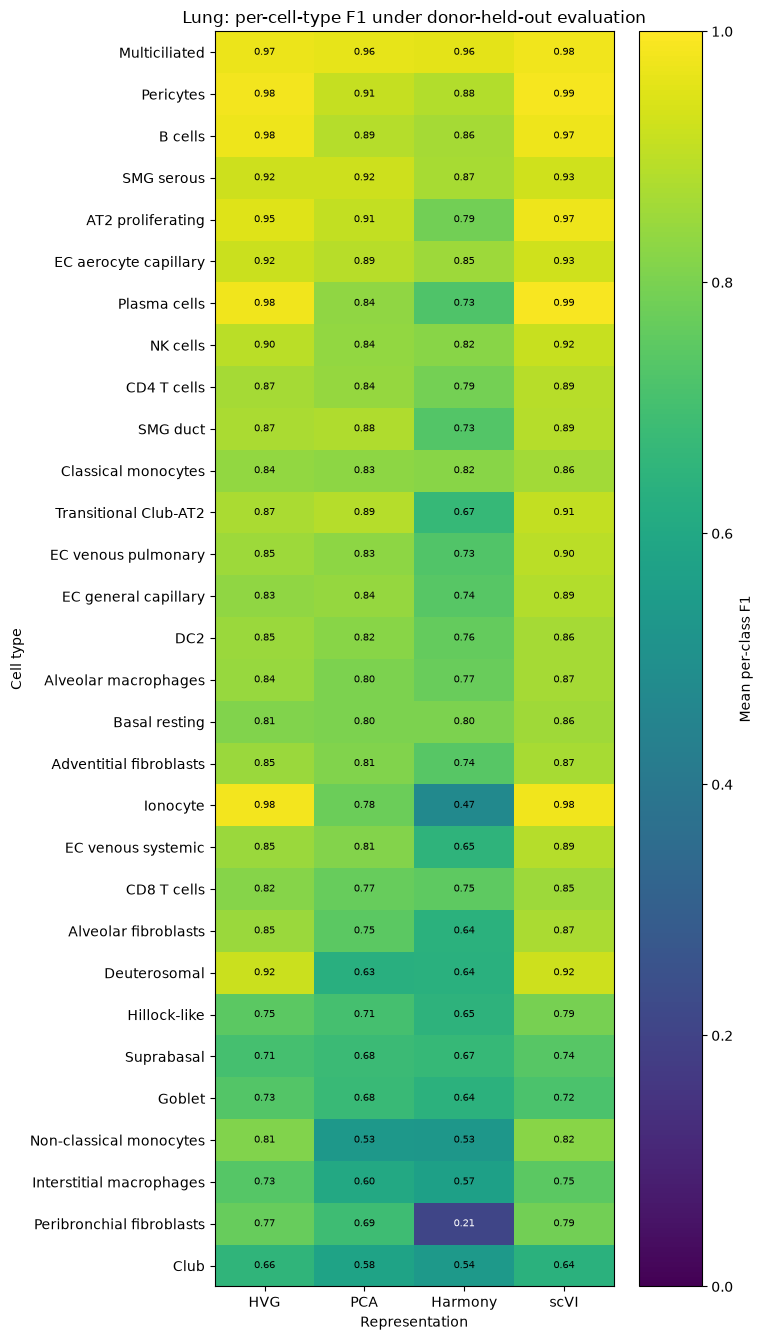

In [10]:
per_class_f1 = load_per_class_f1_matrix(
    donor_cv_dir=config_no_batch.donor_cv_output_dir,
    rep_order=REP_ORDER,
)

display(per_class_f1)

fig, ax = plot_per_class_f1_heatmap(
    f1_matrix=per_class_f1,
    rep_order=REP_ORDER,
    rep_labels=REP_LABELS,
    annotate=True,
    out_file=(
        figures_dir
        / "per_class_f1_heatmap.png"
    ),
    title=(
        "Lung: per-cell-type F1 under "
        "donor-held-out evaluation"
    ),
)

plt.show()

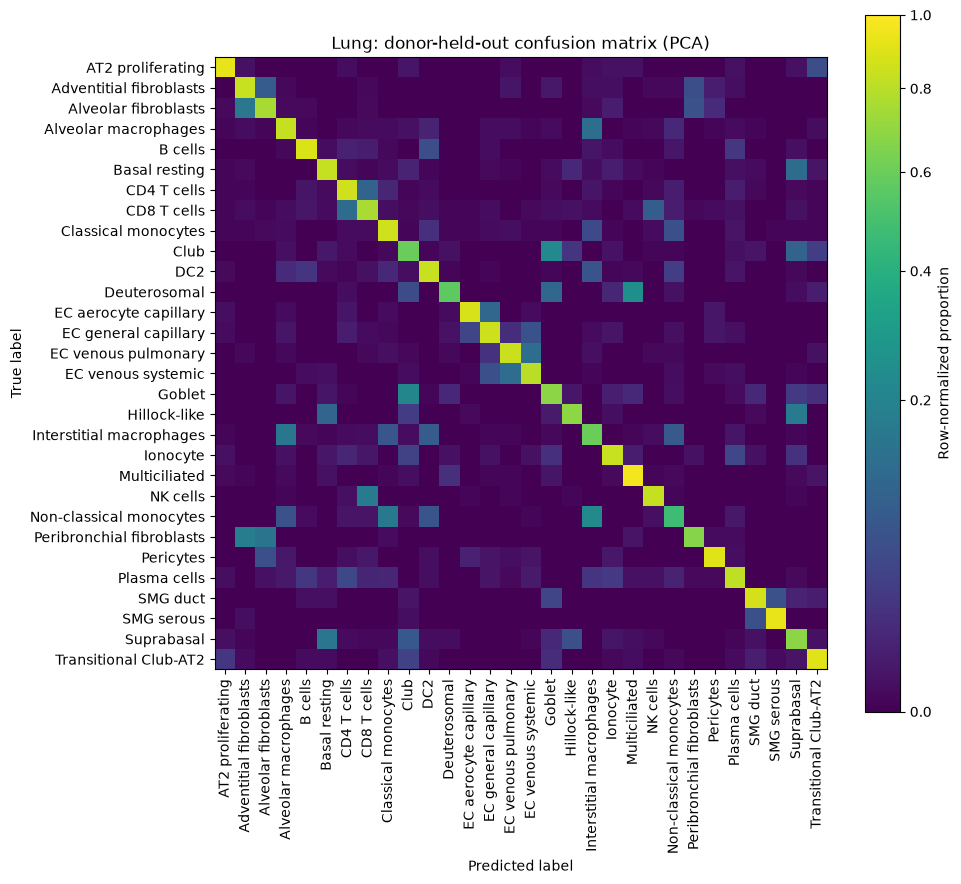

In [11]:
pca_predictions = (
    config_no_batch.donor_cv_output_dir
    / "donor_cv_pca_all_predictions.csv"
)

fig, ax, pca_cm = plot_confusion_matrix_from_predictions(
    predictions=pca_predictions,
    out_file=(
        figures_dir
        / "confusion_matrix_pca_donor_cv.png"
    ),
    title="Lung: donor-held-out confusion matrix (PCA)",
    gamma=0.5,
)

plt.show()

In [12]:
from scrna_benchmark.mixed_models import (
    run_correctness_glmm_analysis,
)

adata_benchmark = outputs_no_batch["prepared"]["adata"]

glmm_dir = (
    config_no_batch.dataset_output_dir
    / "mixed_models"
)

glmm_outputs = run_correctness_glmm_analysis(
    adata=adata_benchmark,
    representations=config_no_batch.representations,
    out_dir=glmm_dir,

    celltype_col=config_no_batch.celltype_col,
    donor_col=config_no_batch.donor_col,

    # retain source dataset in prediction metadata;
    # it is not part of this GLMM's fixed effects
    site_col="batch",

    # GLMM corresponds to the primary no-batch benchmark
    batch_col=None,

    test_size=config_no_batch.test_size,
    n_random_repeats=config_no_batch.random_split_n_repeats,
    n_folds=config_no_batch.n_folds,
    random_state=config_no_batch.random_state,

    dataset_name=config_no_batch.dataset_name,
    verbose=True,
)

display(glmm_outputs["summary"])

Fitting correctness GLMM for harmony
Fitting correctness GLMM for hvg


/users/xchen5/scRNA-cross-donor-generalization/src/scrna_benchmark/mixed_models.py:358: ConvergenceWarning: VB fitting did not converge
  result = model.fit_vb()


Fitting correctness GLMM for pca
Fitting correctness GLMM for scvi


,representation,scheme,pred_prob_correct,coef_intercept,coef_scheme_comparison,scheme_coef_name
0,harmony,donor_held_out,0.737109,1.030997,0.058532,C(scheme)[T.random]
1,harmony,random,0.748293,1.030997,0.058532,C(scheme)[T.random]
2,hvg,donor_held_out,0.844582,1.692725,0.145866,C(scheme)[T.random]
3,hvg,random,0.862782,1.692725,0.145866,C(scheme)[T.random]
4,pca,donor_held_out,0.789189,1.320042,0.072909,C(scheme)[T.random]
5,pca,random,0.801063,1.320042,0.072909,C(scheme)[T.random]
6,scvi,donor_held_out,0.862498,1.836194,0.060629,C(scheme)[T.random]
7,scvi,random,0.869532,1.836194,0.060629,C(scheme)[T.random]


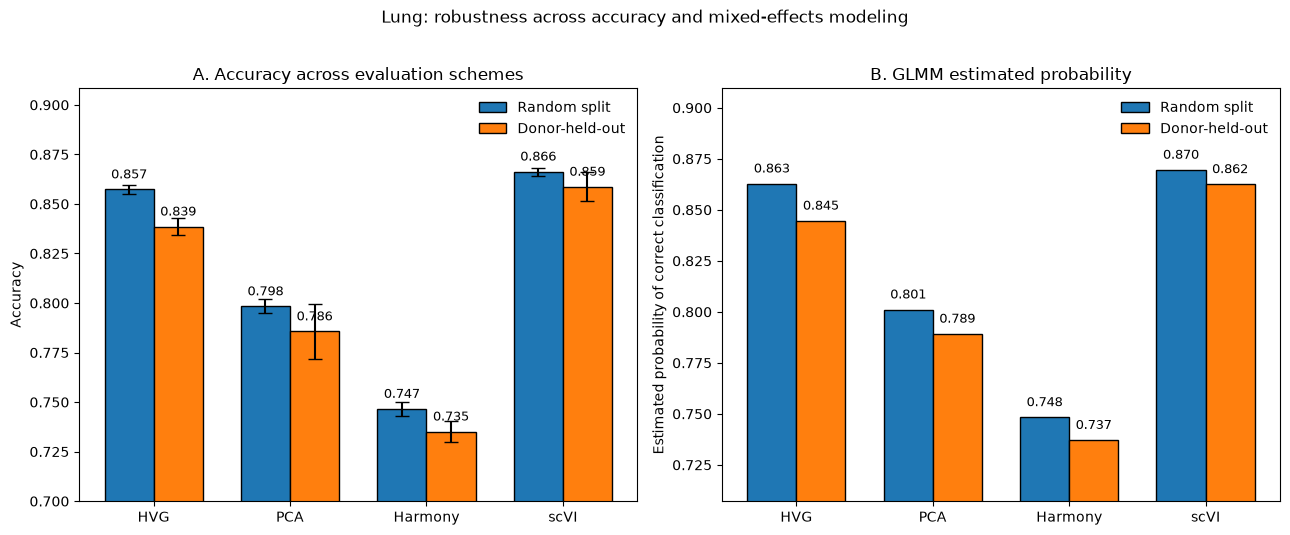

In [13]:
fig, axes = plot_glmm_scheme_comparison(
    random_metrics=(
        config_no_batch.random_output_dir
        / "random_split_repeated_metrics.csv"
    ),
    donor_metrics=(
        config_no_batch.donor_cv_output_dir
        / "metrics.csv"
    ),
    glmm_summary=glmm_outputs["summary"],

    rep_order=REP_ORDER,
    rep_labels=REP_LABELS,

    out_file=(
        figures_dir
        / "glmm_scheme_sensitivity.png"
    ),

    title=(
        "Lung: robustness across accuracy "
        "and mixed-effects modeling"
    ),
)

plt.show()